In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, recall_score, roc_curve,
                             brier_score_loss, precision_recall_curve,
                             average_precision_score)
%matplotlib inline
warnings.filterwarnings('ignore')


In [2]:
BASE_DIR = "../"
DATA_PATH = os.path.join(BASE_DIR, "data", "cancer_data_eng.csv")
IMG_DIR = os.path.join(BASE_DIR, "img")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
RANDOM_STATE = 42
N_SAMPLES = 80000

In [3]:
print("\n[0] 加载数据...")
df = pd.read_csv(DATA_PATH, low_memory=False, encoding='latin-1')
df['target'] = df['Status.Vital'].map({'VIVO': 1, 'MORTO': 0})
df = df.dropna(subset=['target'])

np.random.seed(RANDOM_STATE)
if len(df) > N_SAMPLES:
    idx = np.random.choice(len(df), N_SAMPLES, replace=False)
    df = df.iloc[idx].copy()

print(f"    样本量: {len(df):,}  (VIVO: {(df['target'] == 1).sum():,} | {(df['target'] == 1).mean() * 100:.2f}%)")



[0] 加载数据...
    样本量: 80,000  (VIVO: 32,845 | 41.06%)


In [4]:
# ---------- 选基础特征 ----------
base_features = ['Age', 'year', 'Gender', 'Code.Profession', 'Diagnostic.means', 'Raca.Color']
df_feat = df[base_features + ['target']].copy()

# 标签编码分类变量
cat_cols = ['Gender', 'Diagnostic.means', 'Raca.Color']
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    non_null = df_feat[col].dropna().astype(str)
    le.fit(non_null)
    most_common = non_null.value_counts().index[0]
    def encode(x):
        if pd.isna(x):
            return np.nan
        xs = str(x)
        return le.transform([xs])[0] if xs in le.classes_ else le.transform([most_common])[0]
    df_feat[col] = df_feat[col].apply(encode)
    label_encoders[col] = le

df_feat = df_feat.astype(float)
print(f"    基础特征: {base_features}")

    基础特征: ['Age', 'year', 'Gender', 'Code.Profession', 'Diagnostic.means', 'Raca.Color']


# 第一部分: 数据标准化比较

In [5]:

# 用均值插补处理缺失
imputer = SimpleImputer(strategy='mean')
X_raw_arr = imputer.fit_transform(df_feat[base_features])

# 划分
y = df_feat['target'].values
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw_arr, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

feature_names = base_features  # 保持列名一致

# 定义标准化方法
scalers = {
    'Raw (No Scaling)': None,
    'StandardScaler': StandardScaler(),
    'RobustScaler': RobustScaler(),
}


  ▶ Raw (No Scaling)
      AUC=0.8698  Recall=0.9026  Brier=0.1437
      收敛迭代=162  耗时=0.271s  |系数均值|=0.3482

  ▶ StandardScaler
      AUC=0.8698  Recall=0.9026  Brier=0.1437
      收敛迭代=10  耗时=0.021s  |系数均值|=0.6672

  ▶ RobustScaler
      AUC=0.8698  Recall=0.9026  Brier=0.1436
      收敛迭代=11  耗时=0.046s  |系数均值|=1.1986


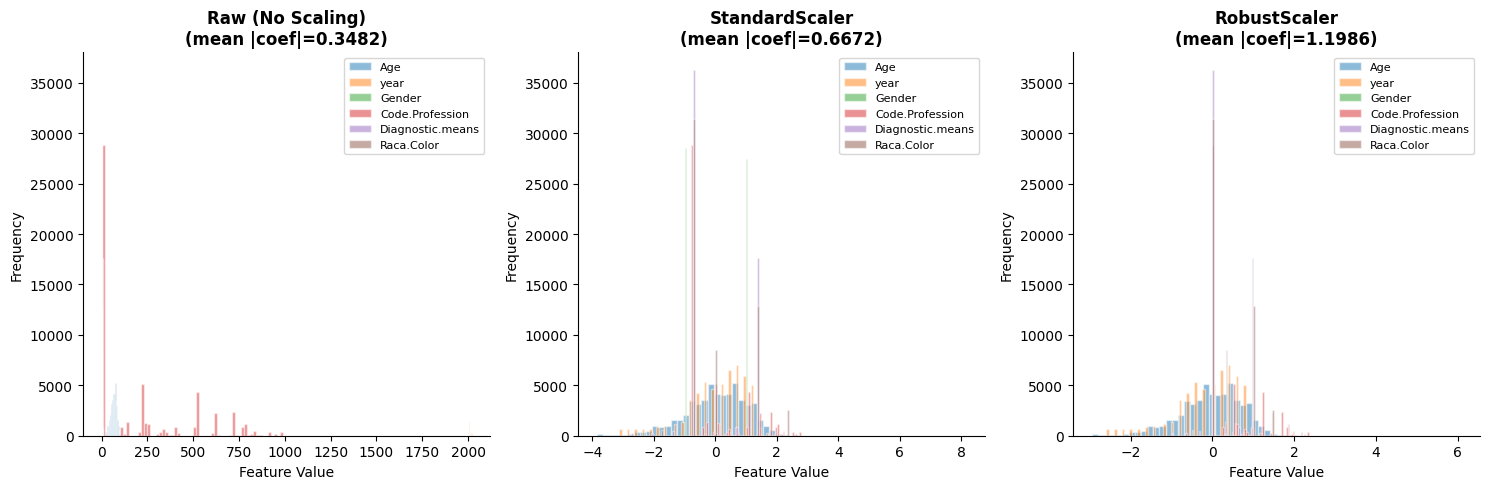

In [6]:

scaler_results = []

fig_scale, axes_scale = plt.subplots(1, 3, figsize=(15, 5))
fig_coef, ax_coef = plt.subplots(figsize=(10, 6))

# 收集系数用于对比
coef_data = {}

for idx, (name, scaler) in enumerate(scalers.items()):
    print(f"\n  ▶ {name}")

    # 标准化
    if scaler is not None:
        X_train = scaler.fit_transform(X_train_raw)
        X_test = scaler.transform(X_test_raw)
    else:
        X_train = X_train_raw.copy()
        X_test = X_test_raw.copy()

    # 训练 LR
    lr = LogisticRegression(
        class_weight='balanced',
        max_iter=5000,
        random_state=RANDOM_STATE,
        solver='lbfgs',
        tol=1e-5
    )

    start = time.time()
    lr.fit(X_train, y_train)
    elapsed = time.time() - start
    n_iter = lr.n_iter_[0]

    # 预测
    y_prob = lr.predict_proba(X_test)[:, 1]
    y_pred = lr.predict(X_test)

    # 评估
    auc = roc_auc_score(y_test, y_prob)
    recall = recall_score(y_test, y_pred, pos_label=1)
    brier = brier_score_loss(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)

    # 系数幅度
    coef_mean_abs = np.abs(lr.coef_[0]).mean()

    scaler_results.append({
        'Scaler': name,
        'AUC': auc,
        'Recall': recall,
        'Brier': brier,
        'PR_AUC': ap,
        'Iterations': n_iter,
        'Time': elapsed,
        '|Coeff|_mean': coef_mean_abs
    })

    coef_data[name] = lr.coef_[0]

    print(f"      AUC={auc:.4f}  Recall={recall:.4f}  Brier={brier:.4f}")
    print(f"      收敛迭代={n_iter}  耗时={elapsed:.3f}s  |系数均值|={coef_mean_abs:.4f}")

    # --- 绘制分布对比 ---
    ax = axes_scale[idx]
    for j, col_name in enumerate(feature_names):
        data_j = X_train[:, j]
        ax.hist(data_j, bins=60, alpha=0.5, label=col_name, edgecolor='white')
    ax.set_title(f'{name}\n(mean |coef|={coef_mean_abs:.4f})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # --- 系数对比 ---
    x_pos = np.arange(len(feature_names)) + idx * 0.25
    ax_coef.bar(x_pos, np.abs(lr.coef_[0]), width=0.2, label=name, alpha=0.8)

plt.suptitle('Feature Distribution After Scaling', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "07a_scaling_distribution.png"), dpi=150, bbox_inches='tight')
plt.close()

ax_coef.set_xticks(np.arange(len(feature_names)) + 0.25)
ax_coef.set_xticklabels(feature_names, fontsize=10)
ax_coef.set_ylabel('|Coefficient| (abs)', fontsize=12)
ax_coef.set_title('Logistic Regression Coefficients by Scaling Method',
                   fontsize=14, fontweight='bold')
ax_coef.legend(fontsize=9)
ax_coef.spines['top'].set_visible(False)
ax_coef.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "07b_coefficient_comparison.png"), dpi=150, bbox_inches='tight')
# plt.close()

# 保存标准化结果
scaler_df = pd.DataFrame(scaler_results)
scaler_df.to_csv(os.path.join(RESULTS_DIR, "09_scaling_comparison.csv"),
                 index=False, encoding='utf-8-sig')

  [图] 07c_scaling_performance.png → 标准化性能对比已保存


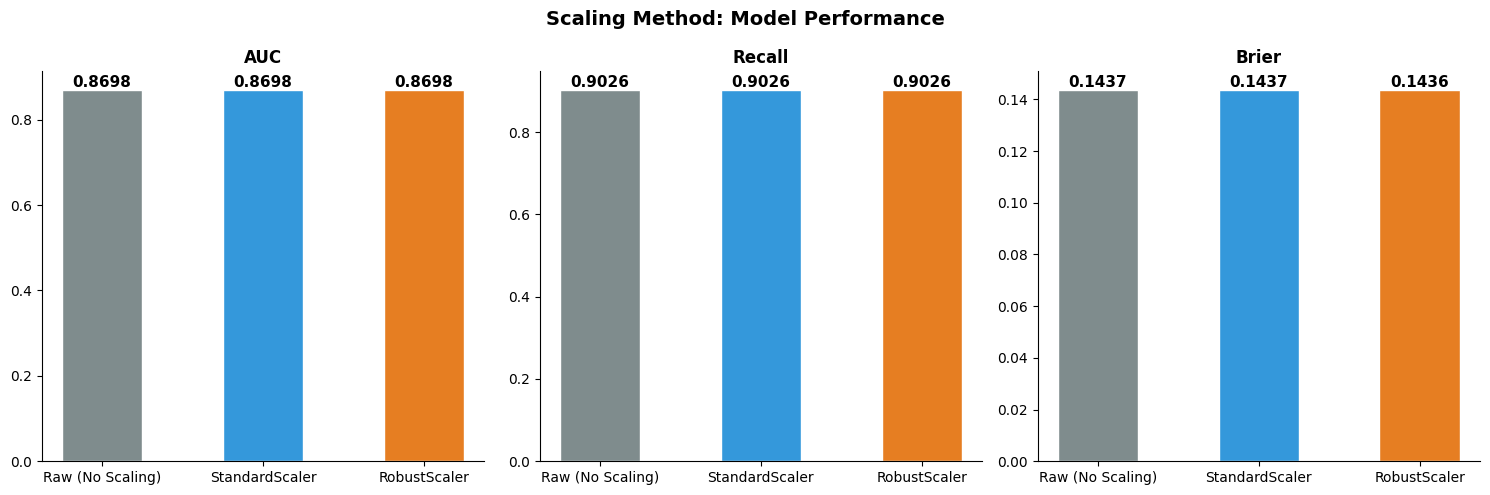

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, metric in enumerate(['AUC', 'Recall', 'Brier']):
    ax = axes[i]
    names = [r['Scaler'] for r in scaler_results]
    vals = [r[metric] for r in scaler_results]
    colors_bar = ['#7f8c8d', '#3498db', '#e67e22']
    bars = ax.bar(names, vals, color=colors_bar, edgecolor='white', width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Scaling Method: Model Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "07c_scaling_performance.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 07c_scaling_performance.png → 标准化性能对比已保存")

  [图] 07d_convergence_speed.png → 收敛速度对比已保存


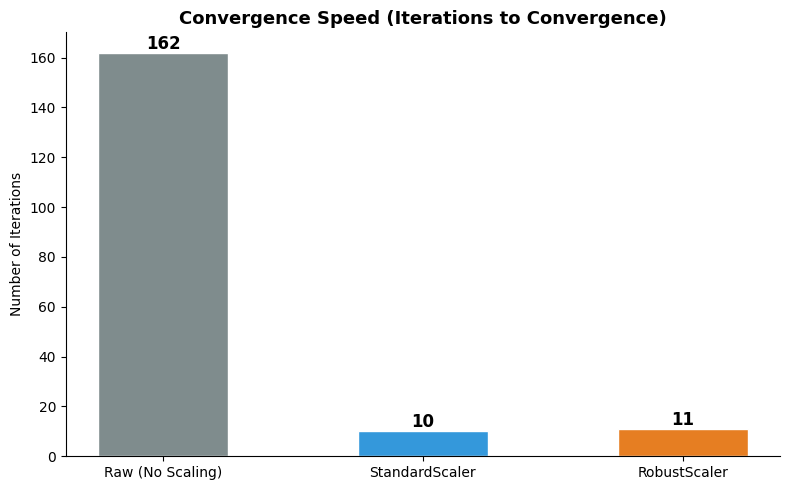

In [8]:

# 收敛迭代次数对比
fig, ax = plt.subplots(figsize=(8, 5))
names = [r['Scaler'] for r in scaler_results]
iters = [r['Iterations'] for r in scaler_results]
colors_bar = ['#7f8c8d', '#3498db', '#e67e22']
bars = ax.bar(names, iters, color=colors_bar, edgecolor='white', width=0.5)
for bar, val in zip(bars, iters):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{int(val)}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Convergence Speed (Iterations to Convergence)', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Iterations')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "07d_convergence_speed.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 07d_convergence_speed.png → 收敛速度对比已保存")

# 第二部分: 特征构造

In [9]:

# 重新准备原始特征 DataFrame (用于构造)
df_eng = df_feat[base_features].copy()
df_eng['target'] = df_feat['target'].values

# ---------- 构造新特征 (基于医学领域知识) ----------

# 特征 1: Age_Group — 年龄分组 (医学上的重要意义)
def age_group(a):
    if pd.isna(a):
        return np.nan
    a = float(a)
    if a < 18:
        return 0   # 儿童/青少年
    elif a < 40:
        return 1   # 中青年
    elif a < 60:
        return 2   # 中年
    elif a < 75:
        return 3   # 老年
    else:
        return 4   # 高龄

df_eng['Age_Group'] = df_eng['Age'].apply(age_group)

# 特征 2: Age_Squared — 年龄平方 (捕捉非线性效应: 存活率可能在两端最低)
df_eng['Age_Sq'] = df_eng['Age'] ** 2

# 特征 3: Year_Decade — 诊断年代 (医学技术随时间进步)
def year_decade(y):
    if pd.isna(y):
        return np.nan
    y = int(y)
    if y < 2005:
        return 0   # 2000-2004
    elif y < 2010:
        return 1   # 2005-2009
    else:
        return 2   # 2010+

df_eng['Year_Decade'] = df_eng['year'].apply(year_decade)

# 特征 4: Year_Since_2000 — 距离2000年的年数 (连续趋势)
df_eng['Year_From_2000'] = df_eng['year'] - 2000

# 特征 5: Gender × Age_Group — 交互特征 (不同性别的年龄效应不同)
df_eng['Gender_x_AgeGroup'] = df_eng['Gender'] * df_eng['Age_Group']

# 特征 6: Is_Child — 是否为儿童癌症 (0-18 岁有特殊临床意义)
df_eng['Is_Child'] = (df_eng['Age'] < 18).astype(float)
df_eng.loc[df_eng['Age'].isna(), 'Is_Child'] = np.nan

# 特征 7: Age_Centered — 年龄中心化 (提高可解释性)
df_eng['Age_Centered'] = df_eng['Age'] - 60

# 列出构造的特征
engineered_features = ['Age_Group', 'Age_Sq', 'Year_Decade',
                       'Year_From_2000', 'Gender_x_AgeGroup',
                       'Is_Child', 'Age_Centered']
print(f"\n  构造的新特征 ({len(engineered_features)} 个):")
for feat in engineered_features:
    n_miss = df_eng[feat].isnull().sum()
    print(f"     {feat:<25} 缺失: {n_miss:>6,}")


  构造的新特征 (7 个):
     Age_Group                 缺失:    117
     Age_Sq                    缺失:    117
     Year_Decade               缺失:      0
     Year_From_2000            缺失:      0
     Gender_x_AgeGroup         缺失:    117
     Is_Child                  缺失:    117
     Age_Centered              缺失:    117


In [10]:

# 处理缺失
imputer_feat = SimpleImputer(strategy='mean')

# 基础特征集
X_base_raw = imputer_feat.fit_transform(df_eng[base_features])

# 全部特征集 (基础 + 构造)
all_feat_names = base_features + engineered_features
X_all_raw = imputer_feat.fit_transform(df_eng[all_feat_names])

# 划分
y_eng = df_eng['target'].values

X_base_train, X_base_test, y_eng_train, y_eng_test = train_test_split(
    X_base_raw, y_eng, test_size=0.3, random_state=RANDOM_STATE, stratify=y_eng
)
X_all_train, X_all_test, _, _ = train_test_split(
    X_all_raw, y_eng, test_size=0.3, random_state=RANDOM_STATE, stratify=y_eng
)

# 标准化
scaler_std = StandardScaler()
X_base_train_s = scaler_std.fit_transform(X_base_train)
X_base_test_s = scaler_std.transform(X_base_test)
X_all_train_s = scaler_std.fit_transform(X_all_train)
X_all_test_s = scaler_std.transform(X_all_test)

# 训练
fe_sets = {
    'Base (6 features)': (X_base_train_s, X_base_test_s, 6),
    'Engineered (13 features)': (X_all_train_s, X_all_test_s, len(all_feat_names)),
}


     --- Base (6 features) (6 个特征) ---
      AUC=0.8698  Recall=0.9026  Brier=0.1437  PR-AUC=0.7412

     --- Engineered (13 features) (13 个特征) ---
      AUC=0.8737  Recall=0.8886  Brier=0.1409  PR-AUC=0.7530


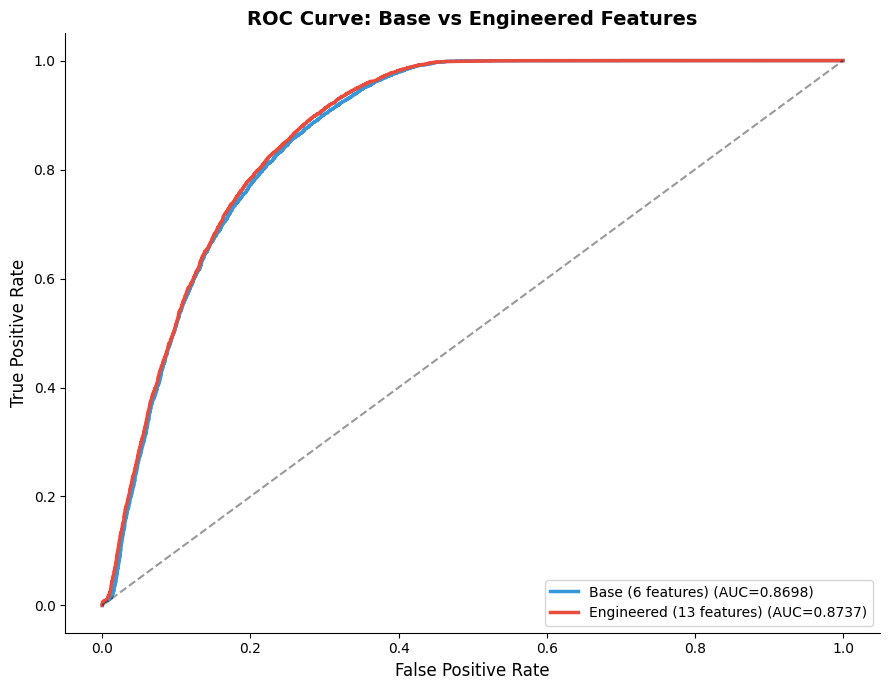

In [11]:

fe_results = []

fig_roc, ax_roc = plt.subplots(figsize=(9, 7))
fig_pr, ax_pr = plt.subplots(figsize=(9, 7))

colors_fe = {'Base (6 features)': '#3498db', 'Engineered (13 features)': '#e74c3c'}

for set_name, (X_tr, X_te, n_feat) in fe_sets.items():
    print(f"\n     --- {set_name} ({n_feat} 个特征) ---")

    lr_fe = LogisticRegression(
        class_weight='balanced',
        max_iter=5000,
        random_state=RANDOM_STATE,
        solver='lbfgs'
    )
    start = time.time()
    lr_fe.fit(X_tr, y_eng_train)
    elapsed = time.time() - start

    y_prob_fe = lr_fe.predict_proba(X_te)[:, 1]
    y_pred_fe = lr_fe.predict(X_te)

    auc_fe = roc_auc_score(y_eng_test, y_prob_fe)
    recall_fe = recall_score(y_eng_test, y_pred_fe, pos_label=1)
    brier_fe = brier_score_loss(y_eng_test, y_prob_fe)
    ap_fe = average_precision_score(y_eng_test, y_prob_fe)

    fe_results.append({
        'Feature_Set': set_name,
        'N_Features': n_feat,
        'AUC': auc_fe,
        'Recall': recall_fe,
        'Brier': brier_fe,
        'PR_AUC': ap_fe,
        'Time': elapsed
    })

    print(f"      AUC={auc_fe:.4f}  Recall={recall_fe:.4f}  Brier={brier_fe:.4f}  PR-AUC={ap_fe:.4f}")

    # ROC
    fpr, tpr, _ = roc_curve(y_eng_test, y_prob_fe)
    ax_roc.plot(fpr, tpr, color=colors_fe[set_name], linewidth=2.5,
                label=f'{set_name} (AUC={auc_fe:.4f})')

    # PR
    prec, rec, _ = precision_recall_curve(y_eng_test, y_prob_fe)
    ax_pr.plot(rec, prec, color=colors_fe[set_name], linewidth=2.5,
               label=f'{set_name} (AP={ap_fe:.4f})')

ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax_roc.set_xlabel('False Positive Rate', fontsize=12)
ax_roc.set_ylabel('True Positive Rate', fontsize=12)
ax_roc.set_title('ROC Curve: Base vs Engineered Features', fontsize=14, fontweight='bold')
ax_roc.legend(fontsize=10)
ax_roc.spines['top'].set_visible(False)
ax_roc.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "07e_fe_roc_curve.png"), dpi=150, bbox_inches='tight')
plt.close()

ax_pr.set_xlabel('Recall', fontsize=12)
ax_pr.set_ylabel('Precision', fontsize=12)
ax_pr.set_title('PR Curve: Base vs Engineered Features', fontsize=14, fontweight='bold')
ax_pr.legend(fontsize=10)
ax_pr.spines['top'].set_visible(False)
ax_pr.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "07f_fe_pr_curve.png"), dpi=150, bbox_inches='tight')
# plt.close()

# 保存特征构造对比
fe_df = pd.DataFrame(fe_results)
fe_df.to_csv(os.path.join(RESULTS_DIR, "10_feature_engineering_comparison.csv"),
             index=False, encoding='utf-8-sig')

  [图] 07g_fe_performance.png → 特征构造性能对比已保存
  [图] 07e_fe_roc_curve.png → 特征构造 ROC 曲线已保存
  [图] 07f_fe_pr_curve.png → 特征构造 PR 曲线已保存


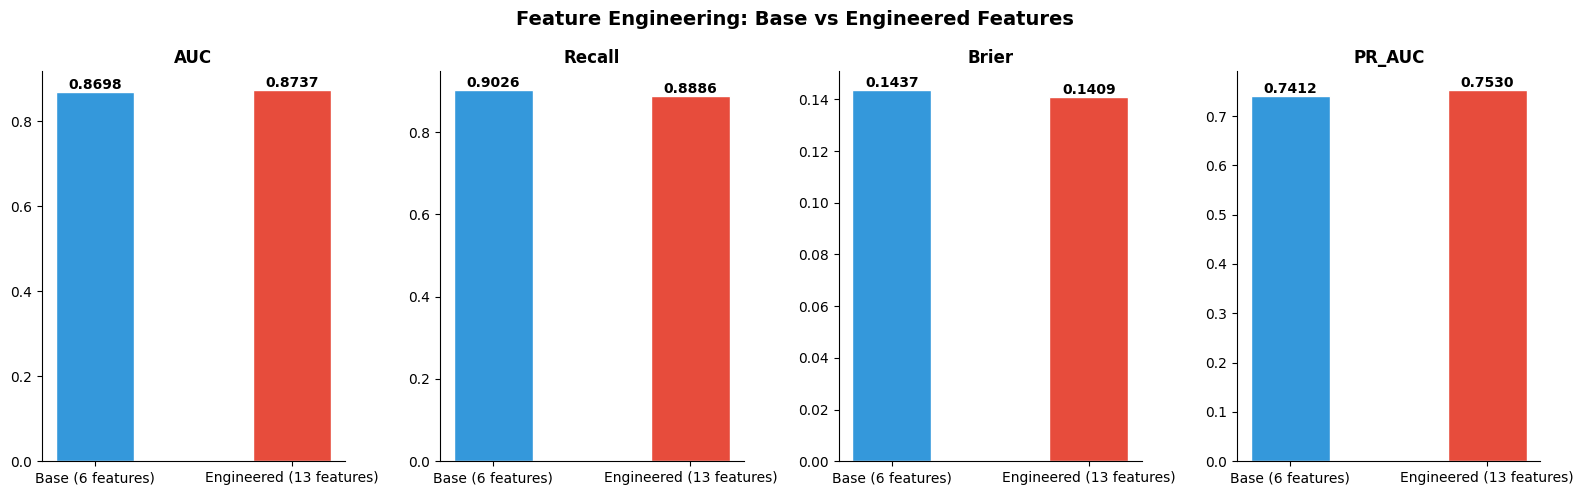

In [12]:
# 性能对比图 (特征构造)
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i, metric in enumerate(['AUC', 'Recall', 'Brier', 'PR_AUC']):
    ax = axes[i]
    names = [r['Feature_Set'] for r in fe_results]
    vals = [r[metric] for r in fe_results]
    colors_b = ['#3498db', '#e74c3c']
    bars = ax.bar(names, vals, color=colors_b, edgecolor='white', width=0.4)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Feature Engineering: Base vs Engineered Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "07g_fe_performance.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 07g_fe_performance.png → 特征构造性能对比已保存")
print("  [图] 07e_fe_roc_curve.png → 特征构造 ROC 曲线已保存")
print("  [图] 07f_fe_pr_curve.png → 特征构造 PR 曲线已保存")